# ⚽ MLS Outcome Prediction Model

This Jupyter notebook provides an interactive, step-by-step exploration of the Major League Soccer (MLS) predictive model using historical data, rolling average feature engineering, and a Random Forest classifier.

## Notebook Contents
1. **Setup & Data Download**: Fetching data directly from Football-Data.co.uk.
2. **Exploratory Data Analysis (EDA)**: Visualizing match outcome distributions and home advantage.
3. **Feature Engineering**: Computing 5-match rolling averages for attack and defense strength with zero data leakage.
4. **Data Splitting**: Splitting the dataset chronologically (train on 2023-2025; test on late 2025 & 2026).
5. **Model Training & Evaluation**: Training a Random Forest and checking accuracy, precision, and recall.
6. **Feature Importance**: Understanding which indicators matter most.
7. **Interactive Predictions**: Running simulated match predictions.

## 🛠️ Step 1: Dependencies & Configuration

In [10]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

## 📂 Step 2: Data Ingestion & Preprocessing

We check if the file `USA.csv` exists in `../data/`. If not, we download the entire dataset from Football-Data.co.uk. 
We also handle the column naming mapping because extra-league files use `Home`/`Away` and `HG`/`AG`/`Res` instead of standard `HomeTeam`/`AwayTeam`/`FTHG`/`FTAG`/`FTR`.

In [11]:
DATA_DIR = "../data"
CSV_PATH = os.path.join(DATA_DIR, "USA.csv")
DOWNLOAD_URL = "https://www.football-data.co.uk/new/USA.csv"

def download_and_load_data():
    if not os.path.exists(DATA_DIR):
        os.makedirs(DATA_DIR)
        
    if not os.path.exists(CSV_PATH):
        print(f"Downloading MLS data to {CSV_PATH}...")
        response = requests.get(DOWNLOAD_URL, timeout=30)
        response.raise_for_status()
        with open(CSV_PATH, 'wb') as f:
            f.write(response.content)
        print("Download finished!")
    else:
        print(f"MLS data file already exists at {CSV_PATH}")
        
    df = pd.read_csv(CSV_PATH)
    return df

raw_df = download_and_load_data()
print(f"Raw dataset dimensions: {raw_df.shape}")

MLS data file already exists at ../data\USA.csv
Raw dataset dimensions: (6034, 25)


### Column Cleaning & Date Sorting

In [ ]:
def preprocess_mls_data(df):
    # Standardize column headers
    column_mapping = {
        'Home': 'HomeTeam',
        'Away': 'AwayTeam',
        'HG': 'FTHG',
        'AG': 'FTAG',
        'Res': 'FTR'
    }
    df = df.rename(columns=column_mapping)
    
    columns_to_keep = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'Season']
    df = df[columns_to_keep].copy()
    
    # Clean string columns
    df['HomeTeam'] = df['HomeTeam'].astype(str).str.strip()
    df['AwayTeam'] = df['AwayTeam'].astype(str).str.strip()
    df['FTR'] = df['FTR'].astype(str).str.strip()
    
    # Parse dates
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, format='mixed')
    
    # Sort chronologically
    df = df.sort_values('Date').reset_index(drop=True)
    return df

df = preprocess_mls_data(raw_df)
print(f"Cleaned dataset contains {len(df)} matches from {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")

Cleaned dataset contains 6034 matches from 2012-03-10 to 2026-05-25


## 📊 Step 3: Exploratory Data Analysis (EDA)

Let's visualize the distribution of Match Outcomes to check for Home Advantage.

Percentage of Outcomes:
FTR
H    49.519390
A    25.422605
D    25.058005
Name: proportion, dtype: float64


C:\Users\Dakkarm\AppData\Local\Temp\ipykernel_17336\1452386613.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='FTR', order=['H', 'D', 'A'], palette='viridis', ax=ax)


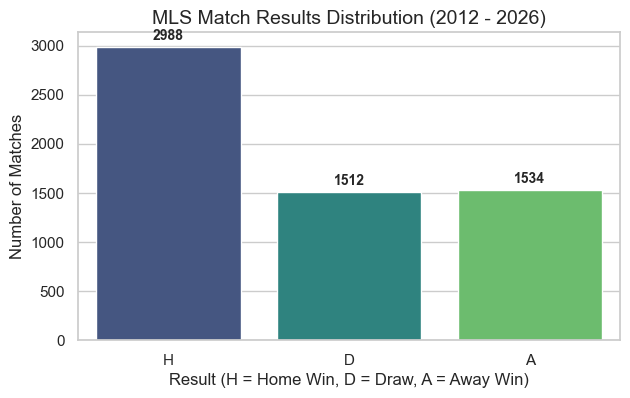

In [13]:
outcome_counts = df['FTR'].value_counts(normalize=True) * 100
print("Percentage of Outcomes:")
print(outcome_counts)

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='FTR', order=['H', 'D', 'A'], palette='viridis', ax=ax)
ax.set_title('MLS Match Results Distribution (2012 - 2026)', fontsize=14)
ax.set_xlabel('Result (H = Home Win, D = Draw, A = Away Win)', fontsize=12)
ax.set_ylabel('Number of Matches', fontsize=12)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.0f}', (p.get_x() + p.get_width() / 2., height + 40),
                ha='center', va='bottom', fontsize=10, weight='bold')
plt.show()

## 📊 Step 4: Feature Engineering (Rolling averages)

To avoid **data leakage**, we must calculate a team's stats *strictly* on matches played before the game day. We group by team, shift goals scored and conceded by 1, and compute rolling averages over a 5-match window.

In [14]:
def compute_rolling_features(df, window=5):
    # Create a long-format DataFrame with one row per team per match
    home_rows = pd.DataFrame({
        'Date': df['Date'],
        'MatchIndex': df.index,
        'Team': df['HomeTeam'],
        'GoalsScored': df['FTHG'],
        'GoalsConceded': df['FTAG'],
        'IsHome': 1
    })
    
    away_rows = pd.DataFrame({
        'Date': df['Date'],
        'MatchIndex': df.index,
        'Team': df['AwayTeam'],
        'GoalsScored': df['FTAG'],
        'GoalsConceded': df['FTHG'],
        'IsHome': 0
    })
    
    team_df = pd.concat([home_rows, away_rows]).sort_values(['Team', 'Date']).reset_index(drop=True)
    
    # Shift history to remove the current match's scores
    team_df['prev_goals_scored'] = team_df.groupby('Team')['GoalsScored'].shift(1)
    team_df['prev_goals_conceded'] = team_df.groupby('Team')['GoalsConceded'].shift(1)
    
    # Calculate rolling averages of the shifted stats
    team_df['attack_rolling'] = team_df.groupby('Team')['prev_goals_scored'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    team_df['defense_rolling'] = team_df.groupby('Team')['prev_goals_conceded'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    
    # Split back to home and away
    home_stats = team_df[team_df['IsHome'] == 1].set_index('MatchIndex')
    away_stats = team_df[team_df['IsHome'] == 0].set_index('MatchIndex')
    
    df_feat = df.copy()
    df_feat['home_attack_rolling'] = home_stats['attack_rolling']
    df_feat['home_defense_rolling'] = home_stats['defense_rolling']
    df_feat['away_attack_rolling'] = away_stats['attack_rolling']
    df_feat['away_defense_rolling'] = away_stats['defense_rolling']
    
    # Drop rows with NaN values (early season games with 0 history)
    feature_cols = ['home_attack_rolling', 'home_defense_rolling', 'away_attack_rolling', 'away_defense_rolling']
    df_feat = df_feat.dropna(subset=feature_cols).reset_index(drop=True)
    
    return df_feat

df_features = compute_rolling_features(df)
print(f"Dataset size after dropping NaNs: {len(df_features)} matches")

Dataset size after dropping NaNs: 6013 matches


### Feature Correlations

Let's see if our engineered features are correlated.

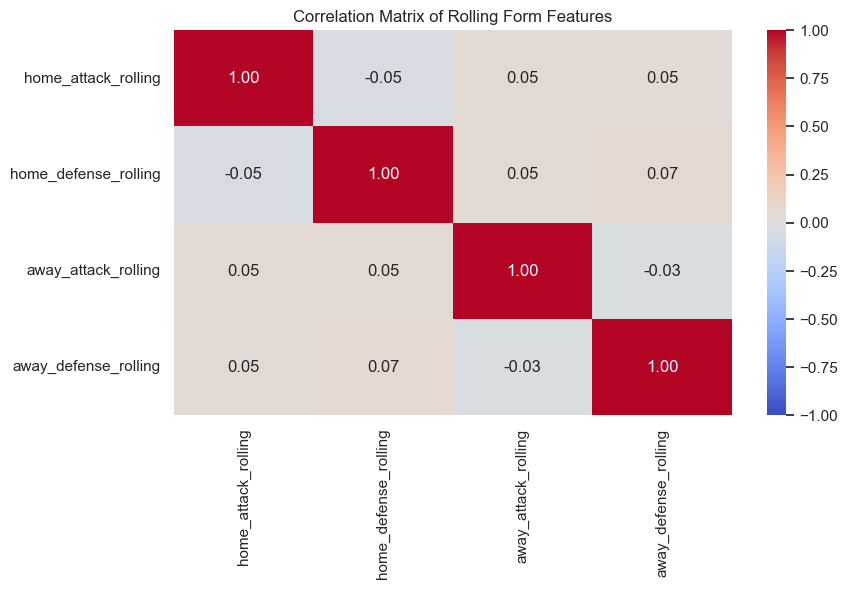

In [15]:
features = ['home_attack_rolling', 'home_defense_rolling', 'away_attack_rolling', 'away_defense_rolling']
corr = df_features[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix of Rolling Form Features')
plt.show()

## 🤖 Step 5: Model Training & Time-Based Split

We split the data chronologically. Train set spans seasons 2023, 2024, and the first half of 2025. Test set covers late 2025 and 2026.

In [16]:
# Target encoding: 'H' -> 2, 'D' -> 1, 'A' -> 0
y_mapping = {'H': 2, 'D': 1, 'A': 0}
df_features['target'] = df_features['FTR'].map(y_mapping)

train_mask = (df_features['Season'].isin([2023, 2024])) | ((df_features['Season'] == 2025) & (df_features['Date'] < '2025-07-01'))
test_mask = ((df_features['Season'] == 2025) & (df_features['Date'] >= '2025-07-01')) | (df_features['Season'] == 2026)

X_train = df_features[train_mask][features]
y_train = df_features[train_mask]['target']
X_test = df_features[test_mask][features]
y_test = df_features[test_mask]['target']

print(f"Train size: {X_train.shape[0]} matches")
print(f"Test size: {X_test.shape[0]} matches")

Train size: 1332 matches
Test size: 467 matches


### Training the Random Forest Classifier

In [17]:
model = RandomForestClassifier(n_estimators=150, max_depth=6, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Away Win (2)', 'Draw (X)', 'Home Win (1)'], zero_division=0))

Accuracy: 0.4732

              precision    recall  f1-score   support

Away Win (2)       0.44      0.13      0.20       142
    Draw (X)       0.40      0.02      0.04       108
Home Win (1)       0.48      0.93      0.63       217

    accuracy                           0.47       467
   macro avg       0.44      0.36      0.29       467
weighted avg       0.45      0.47      0.36       467



## 📊 Step 6: Feature Importance Analysis

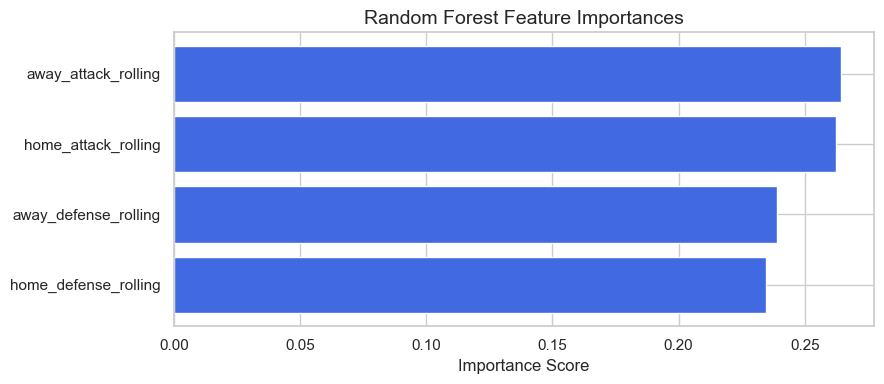

In [18]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_labels = [features[i] for i in indices]

plt.figure(figsize=(9, 4))
plt.barh(range(len(features)), importances[indices][::-1], align='center', color='royalblue')
plt.yticks(range(len(features)), feature_labels[::-1], fontsize=11)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Random Forest Feature Importances', fontsize=14)
plt.tight_layout()
plt.show()

## 🔮 Step 7: Prediction Interface

Let's write a prediction interface where you can simulate match probabilities using the teams' most recent form.

In [19]:
def get_team_form(df, team_name):
    team_matches = df[(df['HomeTeam'] == team_name) | (df['AwayTeam'] == team_name)]
    if len(team_matches) == 0:
        raise ValueError(f"Team '{team_name}' not found.")
    last_5 = team_matches.tail(5)
    
    goals_scored = []
    goals_conceded = []
    for idx, row in last_5.iterrows():
        if row['HomeTeam'] == team_name:
            goals_scored.append(row['FTHG'])
            goals_conceded.append(row['FTAG'])
        else:
            goals_scored.append(row['FTAG'])
            goals_conceded.append(row['FTHG'])
            
    return np.mean(goals_scored), np.mean(goals_conceded)

def predict_match(model, home, away, historical_df):
    try:
        home_att, home_def = get_team_form(historical_df, home)
        away_att, away_def = get_team_form(historical_df, away)
    except ValueError as e:
        print(e)
        return
        
    X_new = pd.DataFrame([{
        'home_attack_rolling': home_att,
        'home_defense_rolling': home_def,
        'away_attack_rolling': away_att,
        'away_defense_rolling': away_def
    }])
    
    probs = model.predict_proba(X_new)[0]
    
    print(f"Match: {home} vs {away}")
    print("========================================")
    print(f"Home Win (1):   {probs[2]*100:.1f}%")
    print(f"Draw (X):       {probs[1]*100:.1f}%")
    print(f"Away Win (2):   {probs[0]*100:.1f}%")
    print("========================================")
    print(f"{home} Form (Last 5) - Attack: {home_att:.2f} G/match | Defense: {home_def:.2f} conceded/match")
    print(f"{away} Form (Last 5) - Attack: {away_att:.2f} G/match | Defense: {away_def:.2f} conceded/match\n")

# Test match simulation
predict_match(model, "Los Angeles Galaxy", "Inter Miami", df)

Match: Los Angeles Galaxy vs Inter Miami
Home Win (1):   43.3%
Draw (X):       20.9%
Away Win (2):   35.7%
Los Angeles Galaxy Form (Last 5) - Attack: 1.40 G/match | Defense: 1.20 conceded/match
Inter Miami Form (Last 5) - Attack: 4.00 G/match | Defense: 2.60 conceded/match



In [20]:
# Try another match
predict_match(model, "New York Red Bulls", "Seattle Sounders", df)

Match: New York Red Bulls vs Seattle Sounders
Home Win (1):   50.6%
Draw (X):       26.4%
Away Win (2):   23.1%
New York Red Bulls Form (Last 5) - Attack: 1.80 G/match | Defense: 1.40 conceded/match
Seattle Sounders Form (Last 5) - Attack: 1.00 G/match | Defense: 1.40 conceded/match

